# Qini and AUUC evaluation



In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir('/Users/beza/hillstrom-email-uplift-modeling')
print("Working directory:", os.getcwd())

Working directory: /Users/beza/hillstrom-email-uplift-modeling


In [2]:
model_files = {
    'Response Baseline': 'outputs/model_results/response_baseline_results.json',
    'S-Learner': 'outputs/model_results/s_learner_results.json',
    'T-Learner': 'outputs/model_results/t_learner_results.json',
    'X-Learner': 'outputs/model_results/x_learner_results.json',
    'Causal Forest': 'outputs/model_results/causal_forest_results.json',
}

results = {}
for name, path in model_files.items():
    with open(path) as f:
        results[name] = json.load(f)
    print(f"Loaded {name}")

Loaded Response Baseline
Loaded S-Learner
Loaded T-Learner
Loaded X-Learner
Loaded Causal Forest


In [3]:
rb_preds = pd.read_csv('outputs/predictions/response_baseline_predictions.csv')
s_preds = pd.read_csv('outputs/predictions/s_learner_predictions.csv')
t_preds = pd.read_csv('outputs/predictions/t_learner_predictions.csv')
x_preds = pd.read_csv('outputs/predictions/tau_hat_x.csv')
cf_preds = pd.read_csv('outputs/predictions/causal_forest_predictions.csv')

treatment_test = pd.read_csv('data/processed/treatment_test.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

print("rb_preds:", rb_preds.shape, rb_preds.columns.tolist())
print("s_preds:", s_preds.shape, s_preds.columns.tolist())
print("t_preds:", t_preds.shape, t_preds.columns.tolist())
print("x_preds:", x_preds.shape, x_preds.columns.tolist())
print("cf_preds:", cf_preds.shape, cf_preds.columns.tolist())
print("treatment_test:", treatment_test.shape)
print("y_test:", y_test.shape)

print("\nRB y_true matches canonical y_test:", (rb_preds['y_true'].values == y_test.values).all())
print("S-Learner y_true matches canonical y_test:", (s_preds['y_true'].values == y_test.values).all())
print("T-Learner y_true matches canonical y_test:", (t_preds['y_true'].values == y_test.values).all())
print("CF y_true matches canonical y_test:", (cf_preds['y_true'].values == y_test.values).all())

rb_preds: (16000, 5) ['y_true', 'logistic_proba', 'logistic_pred', 'xgboost_proba', 'xgboost_pred']
s_preds: (16000, 4) ['y_true', 'treatment', 'tau_hat_lr', 'tau_hat_xgb']
t_preds: (16000, 12) ['y_true', 'treatment', 'segment', 'lgr_pred_visit_if_treated', 'lgr_pred_visit_if_control', 'lgr_predicted_uplift', 'xgb_pred_visit_if_treated', 'xgb_pred_visit_if_control', 'xgb_predicted_uplift', 'rf_pred_visit_if_treated', 'rf_pred_visit_if_control', 'rf_predicted_uplift']
x_preds: (16000, 2) ['index', 'tau_hat_x']
cf_preds: (16000, 4) ['y_true', 'treatment', 'segment', 'cf_predicted_uplift']
treatment_test: (16000,)
y_test: (16000,)

RB y_true matches canonical y_test: True
S-Learner y_true matches canonical y_test: True
T-Learner y_true matches canonical y_test: True
CF y_true matches canonical y_test: True


In [4]:
print(cf_preds[['treatment', 'segment']].drop_duplicates())
print(t_preds[['treatment', 'segment']].drop_duplicates())

   treatment        segment
0          0      No E-Mail
1          1  Womens E-Mail
2          1    Mens E-Mail
   treatment        segment
0          0      No E-Mail
1          1  Womens E-Mail
2          1    Mens E-Mail


In [5]:
print(results['X-Learner']['qini_score'])
print(results['X-Learner']['auuc_score'])

{'X-Learner': 0.04995950953898738}
{'X-Learner': 0.5510278854110819}


In [11]:
from sklift.metrics import qini_auc_score, uplift_auc_score

T_te = treatment_test.values
Y_te = y_test.values


rb_lgr_qini = qini_auc_score(Y_te, rb_preds['logistic_proba'].values, T_te)
rb_lgr_auuc = uplift_auc_score(Y_te, rb_preds['logistic_proba'].values, T_te)
rb_xgb_qini = qini_auc_score(Y_te, rb_preds['xgboost_proba'].values, T_te)
rb_xgb_auuc = uplift_auc_score(Y_te, rb_preds['xgboost_proba'].values, T_te)

print(f"Response Baseline (logistic): Qini={rb_lgr_qini:.4f}  AUUC={rb_lgr_auuc:.4f}")
print(f"Response Baseline (xgboost):  Qini={rb_xgb_qini:.4f}  AUUC={rb_xgb_auuc:.4f}")


s_lr_qini = qini_auc_score(s_preds['y_true'].values, s_preds['tau_hat_lr'].values, s_preds['treatment'].values)
s_lr_auuc = uplift_auc_score(s_preds['y_true'].values, s_preds['tau_hat_lr'].values, s_preds['treatment'].values)
s_xgb_qini = qini_auc_score(s_preds['y_true'].values, s_preds['tau_hat_xgb'].values, s_preds['treatment'].values)
s_xgb_auuc = uplift_auc_score(s_preds['y_true'].values, s_preds['tau_hat_xgb'].values, s_preds['treatment'].values)

print(f"\nS-Learner (logistic): Qini={s_lr_qini:.4f}  AUUC={s_lr_auuc:.4f}")
print(f"S-Learner (xgboost):   Qini={s_xgb_qini:.4f}  AUUC={s_xgb_auuc:.4f}")
t_lgr_qini = qini_auc_score(t_preds['y_true'].values, t_preds['lgr_predicted_uplift'].values, t_preds['treatment'].values)
t_lgr_auuc = uplift_auc_score(t_preds['y_true'].values, t_preds['lgr_predicted_uplift'].values, t_preds['treatment'].values)
t_xgb_qini = qini_auc_score(t_preds['y_true'].values, t_preds['xgb_predicted_uplift'].values, t_preds['treatment'].values)
t_xgb_auuc = uplift_auc_score(t_preds['y_true'].values, t_preds['xgb_predicted_uplift'].values, t_preds['treatment'].values)
t_rf_qini = qini_auc_score(t_preds['y_true'].values, t_preds['rf_predicted_uplift'].values, t_preds['treatment'].values)
t_rf_auuc = uplift_auc_score(t_preds['y_true'].values, t_preds['rf_predicted_uplift'].values, t_preds['treatment'].values)

print(f"\nT-Learner (logistic): Qini={t_lgr_qini:.4f}  AUUC={t_lgr_auuc:.4f}")
print(f"T-Learner (xgboost):   Qini={t_xgb_qini:.4f}  AUUC={t_xgb_auuc:.4f}")
print(f"T-Learner (rf):        Qini={t_rf_qini:.4f}  AUUC={t_rf_auuc:.4f}")

x_qini = qini_auc_score(Y_te, x_preds['tau_hat_x'].values, T_te)
x_auuc = uplift_auc_score(Y_te, x_preds['tau_hat_x'].values, T_te)

print(f"\nX-Learner: Qini={x_qini:.4f}  AUUC={x_auuc:.4f}")

cf_qini = qini_auc_score(cf_preds['y_true'].values, cf_preds['cf_predicted_uplift'].values, cf_preds['treatment'].values)
cf_auuc = uplift_auc_score(cf_preds['y_true'].values, cf_preds['cf_predicted_uplift'].values, cf_preds['treatment'].values)

print(f"\nCausal Forest: Qini={cf_qini:.4f}  AUUC={cf_auuc:.4f}")

Response Baseline (logistic): Qini=0.0340  AUUC=0.0208
Response Baseline (xgboost):  Qini=0.0314  AUUC=0.0192

S-Learner (logistic): Qini=0.0338  AUUC=0.0207
S-Learner (xgboost):   Qini=0.0189  AUUC=0.0116

T-Learner (logistic): Qini=0.0433  AUUC=0.0261
T-Learner (xgboost):   Qini=0.0216  AUUC=0.0130
T-Learner (rf):        Qini=0.0216  AUUC=0.0130

X-Learner: Qini=0.0243  AUUC=0.0145

Causal Forest: Qini=0.0032  AUUC=0.0022


In [13]:
rows = [
    {'Model': 'Response Baseline', 'Base Learner': 'logistic_regression',
     'Qini Score': rb_lgr_qini, 'AUUC Score': rb_lgr_auuc,
     'ROC AUC': results['Response Baseline']['logistic_regression']['roc_auc']},
    {'Model': 'Response Baseline', 'Base Learner': 'xgboost',
     'Qini Score': rb_xgb_qini, 'AUUC Score': rb_xgb_auuc,
     'ROC AUC': results['Response Baseline']['xgboost']['roc_auc']},

    {'Model': 'S-Learner', 'Base Learner': 'logistic_regression',
     'Qini Score': s_lr_qini, 'AUUC Score': s_lr_auuc, 'ROC AUC': np.nan},
    {'Model': 'S-Learner', 'Base Learner': 'xgboost',
     'Qini Score': s_xgb_qini, 'AUUC Score': s_xgb_auuc, 'ROC AUC': np.nan},

    {'Model': 'T-Learner', 'Base Learner': 'logistic_regression',
     'Qini Score': t_lgr_qini, 'AUUC Score': t_lgr_auuc, 'ROC AUC': np.nan},
    {'Model': 'T-Learner', 'Base Learner': 'xgboost',
     'Qini Score': t_xgb_qini, 'AUUC Score': t_xgb_auuc, 'ROC AUC': np.nan},
    {'Model': 'T-Learner', 'Base Learner': 'random_forest',
     'Qini Score': t_rf_qini, 'AUUC Score': t_rf_auuc, 'ROC AUC': np.nan},

    {'Model': 'X-Learner', 'Base Learner': 'random_forest',
     'Qini Score': x_qini, 'AUUC Score': x_auuc, 'ROC AUC': np.nan},

    {'Model': 'Causal Forest', 'Base Learner': 'UpliftRandomForest',
     'Qini Score': cf_qini, 'AUUC Score': cf_auuc, 'ROC AUC': np.nan},
]

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values('Qini Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,Base Learner,Qini Score,AUUC Score,ROC AUC
0,T-Learner,logistic_regression,0.043342,0.026051,NaN
1,Response Baseline,logistic_regression,0.033983,0.020811,0.624535
2,S-Learner,logistic_regression,0.033811,0.020727,NaN
3,Response Baseline,xgboost,0.031354,0.019181,0.614998
4,X-Learner,random_forest,0.024322,0.014458,NaN
5,T-Learner,random_forest,0.021609,0.013021,NaN
6,T-Learner,xgboost,0.021556,0.012978,NaN
7,S-Learner,xgboost,0.018854,0.011641,NaN
8,Causal Forest,UpliftRandomForest,0.003177,0.002235,NaN


In [14]:
print("x_preds length:", len(x_preds))
print("y_test length:", len(y_test))

x_preds length: 16000
y_test length: 16000


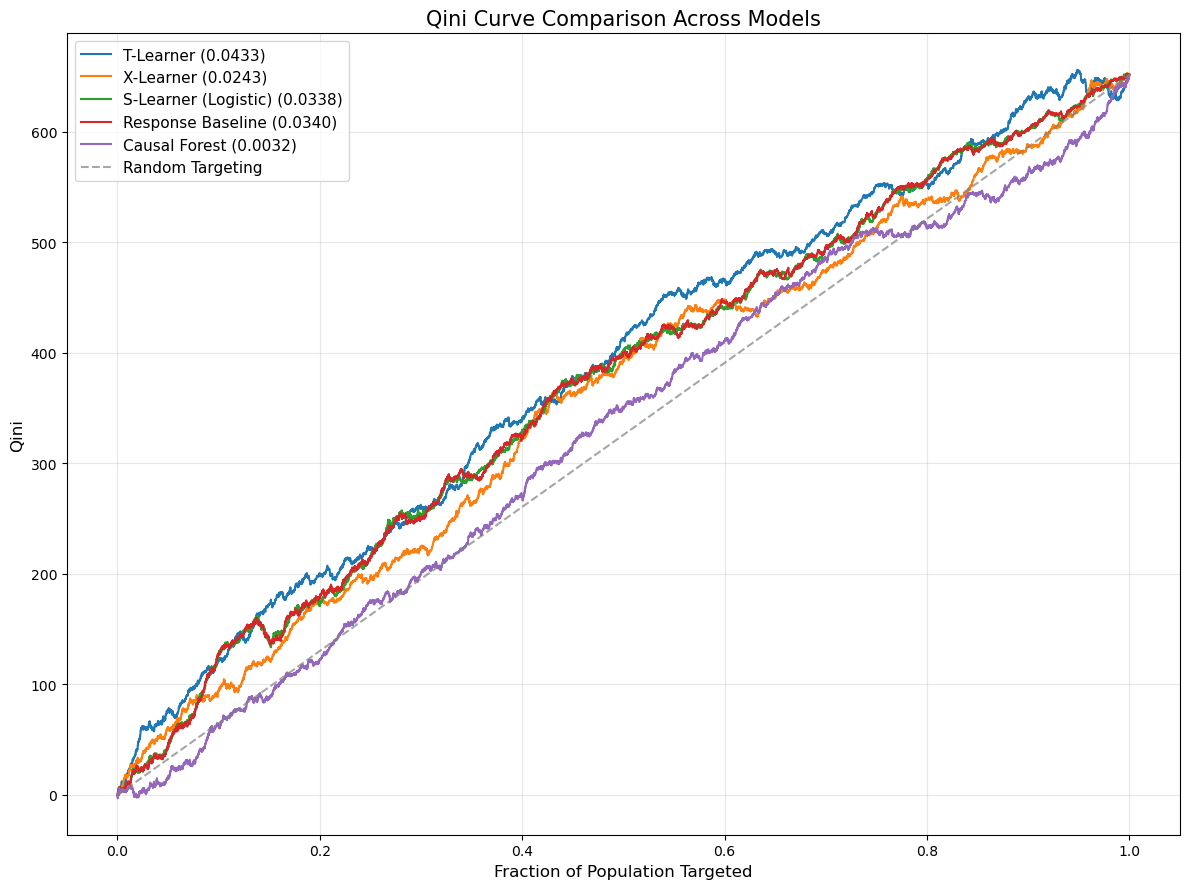

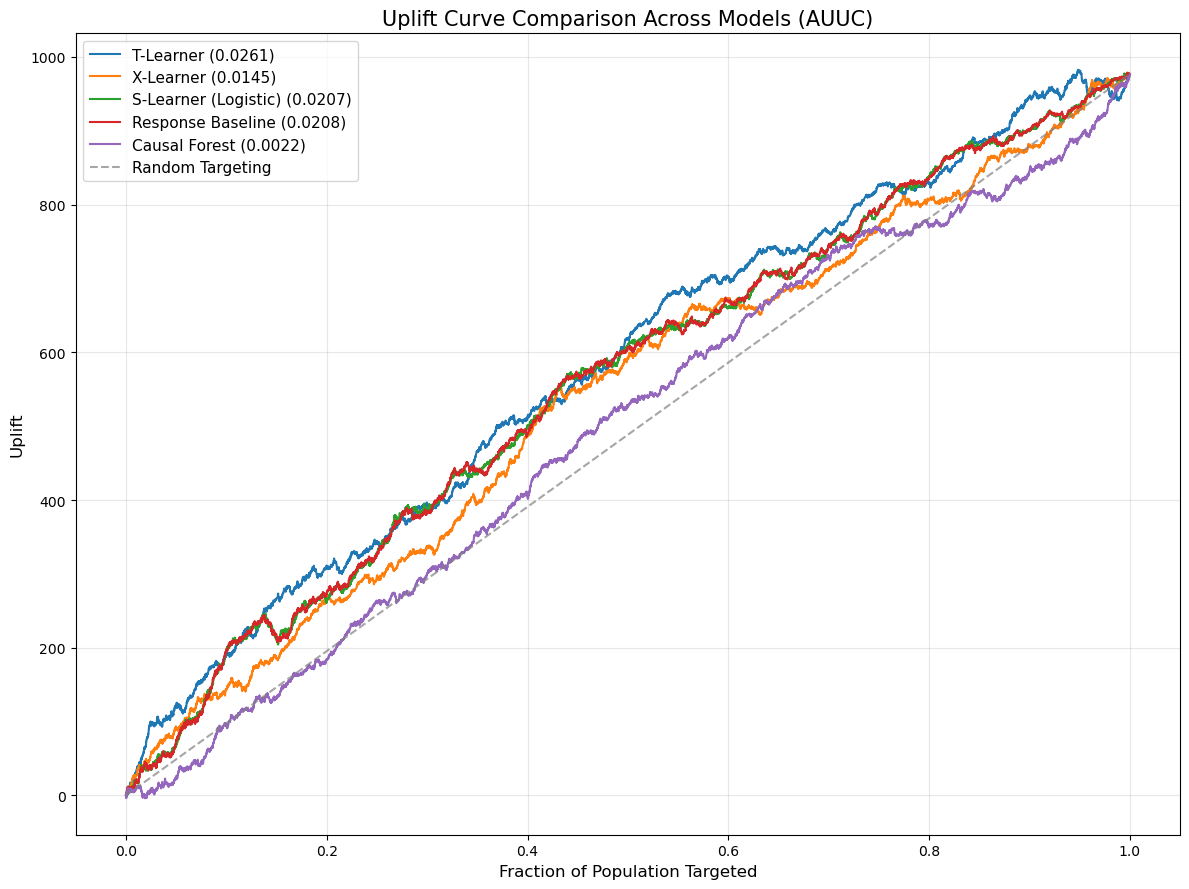

In [15]:
from sklift.metrics import qini_curve, uplift_curve, qini_auc_score, uplift_auc_score

def plot_uplift_style_curve(curve_fn, score_fn, models, random_label_offset=None,
                             title="", ylabel="", filename=None, figsize=(12, 9)):
    """
    models: list of (label, y_true, uplift_pred, treatment) tuples
    curve_fn: qini_curve or uplift_curve
    score_fn: qini_auc_score or uplift_auc_score
    """
    plt.figure(figsize=figsize)
    last_vals = None

    for label, y_true, uplift_pred, treatment in models:
        frac, vals = curve_fn(y_true, uplift_pred, treatment)
        n = frac[-1]                     # total count -> use to normalize x to [0,1]
        x = np.array(frac) / n
        score = score_fn(y_true, uplift_pred, treatment)
        plt.plot(x, vals, label=f"{label} ({score:.4f})", linewidth=1.5)
        last_vals = vals                 # all models share the same endpoint value

    # true random-targeting diagonal: (0,0) -> (1, endpoint)
    plt.plot([0, 1], [0, last_vals[-1]], color="gray", linestyle="--",
              linewidth=1.5, label="Random Targeting", alpha=0.7)

    plt.xlabel("Fraction of Population Targeted", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=15)
    plt.legend(fontsize=11, loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=200)
    plt.show()


models = [
    ("T-Learner",         t_preds["y_true"].values, t_preds["lgr_predicted_uplift"].values, t_preds["treatment"].values),
    ("X-Learner",         y_test.values,             x_preds["tau_hat_x"].values,             treatment_test.values),
    ("S-Learner (Logistic)", s_preds["y_true"].values, s_preds["tau_hat_lr"].values,           s_preds["treatment"].values),
    ("Response Baseline", rb_preds["y_true"].values, rb_preds["logistic_proba"].values,        treatment_test.values),
    ("Causal Forest",     cf_preds["y_true"].values, cf_preds["cf_predicted_uplift"].values,   cf_preds["treatment"].values),
]

plot_uplift_style_curve(
    qini_curve, qini_auc_score, models,
    title="Qini Curve Comparison Across Models",
    ylabel="Qini",
    filename="outputs/figures/model_comparison_qini_curves.png",
)

plot_uplift_style_curve(
    uplift_curve, uplift_auc_score, models,
    title="Uplift Curve Comparison Across Models (AUUC)",
    ylabel="Uplift",
    filename="outputs/figures/model_comparison_uplift_curves.png",
)

## Model Comparison Results

The table above ranks all five uplift modeling approaches by Qini score on the held-out test set, using a consistent scoring method (sklift's `qini_auc_score`/`uplift_auc_score`) across every model. The T-Learner using logistic regression as its base learner achieved the highest Qini score at 0.0433 and the highest AUUC at 0.0261, making it the strongest performer in this comparison.

Somewhat surprisingly, the naive Response Baseline (logistic) and S-Learner (logistic) models placed second and third, with Qini scores of 0.0340 and 0.0338 respectively — both ahead of the X-Learner (0.0243). The T-Learner's random forest and XGBoost variants scored lower still, at 0.0216 each, essentially tied with each other despite using different base learners (confirmed their underlying predictions are not identical). The S-Learner (xgboost) trailed further behind at 0.0189.

The Causal Forest produced the lowest score in this comparison, with a Qini of 0.0032 and an AUUC of 0.0022 on the single test split. Five-fold cross-validation of the Causal Forest, however, showed a mean Qini score of 0.0165, considerably higher than its single-split result, suggesting that a single train/test split understates its true performance and that the model is more sensitive to how the data is partitioned than the other approaches evaluated here.

Overall, the T-Learner (logistic) delivered the strongest single-split performance in this comparison. Notably, model complexity did not track with performance: the naive Response Baseline and simpler S-Learner outperformed both the X-Learner and the tree-based T-Learner variants, and the Causal Forest — the most sophisticated method evaluated — ranked last on this dataset and evaluation split, though its cross-validated results suggest this single-split ranking may not fully reflect its typical performance.